# Ayudantia 12
Repaso general

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Cargamos los datos
df = pd.read_csv("musicGenre.csv")
data = df.copy()
data.head(5)

,Artist Name,Track Name,Popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Genre_name
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,HipHop
1,Boston,Hitch a Ride,54.0,0.382,0.814,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,Rock
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,Indie
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,HipHop
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,Rock


In [12]:
# Realizamos limpieza

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         1000 non-null   object 
 1   Track Name          1000 non-null   object 
 2   Popularity          973 non-null    float64
 3   danceability        1000 non-null   float64
 4   energy              1000 non-null   float64
 5   loudness            1000 non-null   float64
 6   mode                1000 non-null   int64  
 7   speechiness         1000 non-null   float64
 8   acousticness        1000 non-null   float64
 9   instrumentalness    750 non-null    float64
 10  liveness            1000 non-null   float64
 11  valence             1000 non-null   float64
 12  tempo               1000 non-null   float64
 13  duration_in min/ms  1000 non-null   float64
 14  time_signature      1000 non-null   int64  
 15  Genre_name          1000 non-null   object 
dtypes: floa

Como no nos importa, qué tan popular es el artista o la canción, podemos reemplazar la popularidad con algún valor que ya tenemos como por ejemplo el promedio. 

Supongamos que la columna instrumentalness es muy importante para el análisis, por lo que no nos sirve si el dato tiene esta columna con valor nulo.

In [13]:
data["Popularity"].describe()

count    973.000000
mean      44.514902
std       17.974863
min        1.000000
25%       32.000000
50%       44.000000
75%       57.000000
max       99.000000
Name: Popularity, dtype: float64

In [14]:
data["Popularity"] = data["Popularity"].fillna(data["Popularity"].mean())


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         1000 non-null   object 
 1   Track Name          1000 non-null   object 
 2   Popularity          1000 non-null   float64
 3   danceability        1000 non-null   float64
 4   energy              1000 non-null   float64
 5   loudness            1000 non-null   float64
 6   mode                1000 non-null   int64  
 7   speechiness         1000 non-null   float64
 8   acousticness        1000 non-null   float64
 9   instrumentalness    750 non-null    float64
 10  liveness            1000 non-null   float64
 11  valence             1000 non-null   float64
 12  tempo               1000 non-null   float64
 13  duration_in min/ms  1000 non-null   float64
 14  time_signature      1000 non-null   int64  
 15  Genre_name          1000 non-null   object 
dtypes: floa

In [16]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 750 entries, 1 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         750 non-null    object 
 1   Track Name          750 non-null    object 
 2   Popularity          750 non-null    float64
 3   danceability        750 non-null    float64
 4   energy              750 non-null    float64
 5   loudness            750 non-null    float64
 6   mode                750 non-null    int64  
 7   speechiness         750 non-null    float64
 8   acousticness        750 non-null    float64
 9   instrumentalness    750 non-null    float64
 10  liveness            750 non-null    float64
 11  valence             750 non-null    float64
 12  tempo               750 non-null    float64
 13  duration_in min/ms  750 non-null    float64
 14  time_signature      750 non-null    int64  
 15  Genre_name          750 non-null    object 
dtypes: float

In [17]:
data.head()

,Artist Name,Track Name,Popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Genre_name
1,Boston,Hitch a Ride,54.0,0.382,0.814,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,Rock
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,Indie
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,Rock
5,The Stooges,Search and Destroy - Iggy Pop Mix,53.0,0.235,0.977,0.878,1,0.1070,0.003530,0.006040,0.1720,0.2410,152.952,208133.0,4,Indie
6,Solomon Burke,None Of Us Are Free,48.0,0.674,0.658,-9.647,0,0.1040,0.404000,0.000001,0.0981,0.6770,143.292,329387.0,4,Blues


In [22]:
data = data.drop(["mode","time_signature"], axis=1)
data.head()

,Artist Name,Track Name,Popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,Genre_name
1,Boston,Hitch a Ride,54.0,0.382,0.814,-7.230,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,Rock
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,-8.334,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,Indie
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,-4.279,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,Rock
5,The Stooges,Search and Destroy - Iggy Pop Mix,53.0,0.235,0.977,0.878,0.1070,0.003530,0.006040,0.1720,0.2410,152.952,208133.0,Indie
6,Solomon Burke,None Of Us Are Free,48.0,0.674,0.658,-9.647,0.1040,0.404000,0.000001,0.0981,0.6770,143.292,329387.0,Blues


Queremos analizar cómo se relaciona la columna loudness según el género musical.

In [24]:
data_gen = data.groupby(by="Genre_name").sum()["loudness"]
data_gen

Genre_name
AcousticFolk    -328.146
Alt             -520.203
Blues           -569.242
Bollywood       -113.753
Country         -104.397
HipHop          -265.819
Indie          -1084.667
Instrumental    -475.299
Metal           -498.240
Pop             -573.566
Rock           -1665.521
Name: loudness, dtype: float64

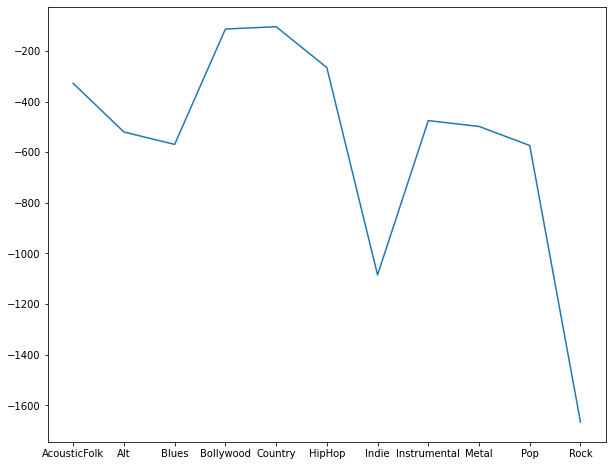

In [26]:
fig = plt.figure(figsize=(10,8))

plt.plot(data_gen.index, data_gen.values)
plt.show()

In [27]:
data.describe()

,Popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms
count,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,7.500000e+02
mean,43.161004,0.533928,0.662990,-8.265137,0.064940,0.248372,0.179730,0.193228,0.472751,122.779708,2.109990e+05
std,17.045630,0.164965,0.240217,3.999931,0.055375,0.315894,0.304277,0.167087,0.244295,29.468187,1.158551e+05
min,1.000000,0.080900,0.014500,-31.366000,0.023100,0.000002,0.000001,0.023300,0.033500,42.956000,1.365333e+00
25%,32.000000,0.431000,0.505000,-10.166250,0.034100,0.002250,0.000074,0.096000,0.278250,100.001750,1.754668e+05
50%,42.500000,0.534000,0.697000,-7.360000,0.044250,0.079400,0.003995,0.124000,0.460000,120.069000,2.152880e+05
75%,55.000000,0.641750,0.869750,-5.413000,0.072200,0.432000,0.207000,0.251750,0.656750,142.093500,2.625068e+05
max,98.000000,0.950000,0.998000,0.878000,0.416000,0.996000,0.972000,0.992000,0.979000,205.057000,1.083755e+06


data.corr()

## Machine Learning

* Modelos y clasificación

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [30]:
data.head()

,Artist Name,Track Name,Popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,Genre_name
1,Boston,Hitch a Ride,54.0,0.382,0.814,-7.230,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,Rock
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,-8.334,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,Indie
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,-4.279,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,Rock
5,The Stooges,Search and Destroy - Iggy Pop Mix,53.0,0.235,0.977,0.878,0.1070,0.003530,0.006040,0.1720,0.2410,152.952,208133.0,Indie
6,Solomon Burke,None Of Us Are Free,48.0,0.674,0.658,-9.647,0.1040,0.404000,0.000001,0.0981,0.6770,143.292,329387.0,Blues


In [33]:
# Eliminamos las columnas que no sirven para definir el género musical
data_clean = data.drop(["Artist Name", "Track Name", "Popularity"], axis=1)
data_clean.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,Genre_name
1,0.382,0.814,-7.230,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,Rock
2,0.434,0.614,-8.334,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,Indie
4,0.167,0.975,-4.279,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,Rock
5,0.235,0.977,0.878,0.1070,0.003530,0.006040,0.1720,0.2410,152.952,208133.0,Indie
6,0.674,0.658,-9.647,0.1040,0.404000,0.000001,0.0981,0.6770,143.292,329387.0,Blues


In [34]:
y = data_clean["Genre_name"]
X = data_clean.drop(["Genre_name"], axis=1)

In [35]:
# Separamos los sets de train y test
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.3)

In [36]:
# Creamos el modelo
forest = RandomForestClassifier()
# Ajustamos el modelo
forest.fit(Xtrain, ytrain)

RandomForestClassifier()

In [37]:
# Predecir
y_pred = forest.predict(Xtest)

In [38]:
from sklearn.metrics import accuracy_score

accuracy_score(ytest, y_pred)

0.4177777777777778

In [41]:
y_pred, ytest

(array(['Indie', 'Blues', 'Rock', 'Rock', 'Rock', 'Rock', 'Rock', 'Rock',
        'Metal', 'Rock', 'Metal', 'Indie', 'Rock', 'Indie', 'Rock',
        'Bollywood', 'Rock', 'HipHop', 'AcousticFolk', 'Rock', 'Rock',
        'Rock', 'Rock', 'Pop', 'Blues', 'Pop', 'Pop', 'Rock', 'Rock',
        'Rock', 'Rock', 'Rock', 'Rock', 'Blues', 'Indie', 'Rock', 'Rock',
        'Rock', 'Rock', 'Indie', 'Rock', 'Pop', 'Rock', 'Rock', 'Rock',
        'Indie', 'Rock', 'Rock', 'Blues', 'Country', 'Indie', 'Blues',
        'HipHop', 'AcousticFolk', 'Indie', 'Country', 'Rock', 'Rock',
        'Indie', 'Metal', 'Rock', 'Rock', 'Rock', 'HipHop', 'Metal',
        'Rock', 'HipHop', 'Rock', 'Blues', 'Rock', 'Rock', 'Rock', 'Indie',
        'Rock', 'Instrumental', 'Metal', 'Rock', 'Rock', 'Rock', 'Rock',
        'HipHop', 'AcousticFolk', 'Indie', 'Rock', 'Metal', 'Pop', 'Rock',
        'Rock', 'Indie', 'Rock', 'Indie', 'Rock', 'Metal', 'Pop', 'Rock',
        'Metal', 'Country', 'Pop', 'Indie', 'Rock', 'Blues', 'A

In [40]:
ytest

934      Alt
84     Blues
860     Rock
915    Indie
314     Rock
       ...  
989    Metal
53       Alt
255      Pop
829    Metal
708    Metal
Name: Genre_name, Length: 225, dtype: object

In [43]:
data_clean.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,Genre_name
1,0.382,0.814,-7.230,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,Rock
2,0.434,0.614,-8.334,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,Indie
4,0.167,0.975,-4.279,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,Rock
5,0.235,0.977,0.878,0.1070,0.003530,0.006040,0.1720,0.2410,152.952,208133.0,Indie
6,0.674,0.658,-9.647,0.1040,0.404000,0.000001,0.0981,0.6770,143.292,329387.0,Blues


In [44]:
# Asumamos que liveness, valence y duration no influyen en el género, por lo tanto eliminaremos estas columnas

data_clean = data_clean.drop(["liveness", "valence", "duration_in min/ms"], axis=1)
data_clean.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,tempo,Genre_name
1,0.382,0.814,-7.230,0.0406,0.001100,0.004010,116.454,Rock
2,0.434,0.614,-8.334,0.0525,0.486000,0.000196,147.681,Indie
4,0.167,0.975,-4.279,0.2160,0.000169,0.016100,199.060,Rock
5,0.235,0.977,0.878,0.1070,0.003530,0.006040,152.952,Indie
6,0.674,0.658,-9.647,0.1040,0.404000,0.000001,143.292,Blues


In [46]:
y = data_clean["Genre_name"]
X = data_clean.drop("Genre_name", axis=1)

In [47]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.3)

In [48]:
forest = RandomForestClassifier()
forest.fit(Xtrain, ytrain)
ypred = forest.predict(Xtest)

In [49]:
accuracy_score(ypred, ytest)

0.37333333333333335

In [60]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(n_neighbors = 7)
KNN.fit(Xtrain, ytrain)
ypred = KNN.predict(Xtest)

In [61]:
accuracy_score(ytest, ypred)

0.24888888888888888